# Locally Weighted Regression

Lab Assignment 4 - fitting a synthetic sinusoidal dataset with a non-parametric Locally Weighted Regression (LWR) model. LWR fits a separate weighted linear regression for every query point, giving more weight to nearby training points and less to far away ones.

## 1. Generate the dataset

Using the seed and formula given in the assignment so the sine curve has some noise added on top.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

np.random.seed(0)
X = np.sort(5 * np.random.rand(80, 1), axis=0)
y = np.sin(X).ravel() + np.random.normal(0, 0.1, X.shape[0])

## Dataset

Quick look at the raw points before fitting anything.

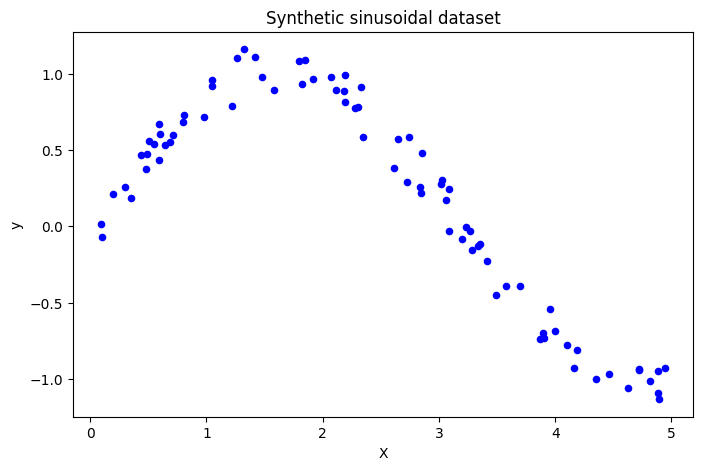

In [2]:
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='blue', s=20)
plt.xlabel('X')
plt.ylabel('y')
plt.title('Synthetic sinusoidal dataset')
plt.show()

## 2. Features and target

X is already the feature (single column) and y is the target, straight from the generation step above.

In [3]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (80, 1)
y shape: (80,)


## 3. Locally Weighted Regression

A Gaussian kernel gives each training point a weight based on how close it is to the query point x0. Those weights go into a diagonal matrix W and get used in a weighted normal equation to solve for the local regression coefficients.

In [4]:
def gaussian_kernel(x0, X, tau):
    return np.exp(-np.sum((X - x0) ** 2, axis=1) / (2 * tau * tau))

def local_regression(x0, X, y, tau):
    X_ = np.c_[np.ones(X.shape[0]), X]
    x0_ = np.r_[1, x0]
    w = gaussian_kernel(x0_, X_, tau)
    W = np.diag(w)
    theta = np.linalg.pinv(X_.T @ W @ X_) @ X_.T @ W @ y
    return x0_ @ theta

## 4. Trying out a few query points

In [5]:
query_points = [1.0, 2.5, 4.0]
tau = 0.5

for x0 in query_points:
    pred = local_regression(x0, X, y, tau)
    print(f"x0 = {x0}, prediction = {pred:.4f}")

x0 = 1.0, prediction = 0.7464
x0 = 2.5, prediction = 0.5761
x0 = 4.0, prediction = -0.6516


## 5. Fitted curves for different bandwidths

Sweeping tau (the bandwidth) changes how "local" the fit is. Small tau values only look at points that are very close by, larger tau values bring in points further away.

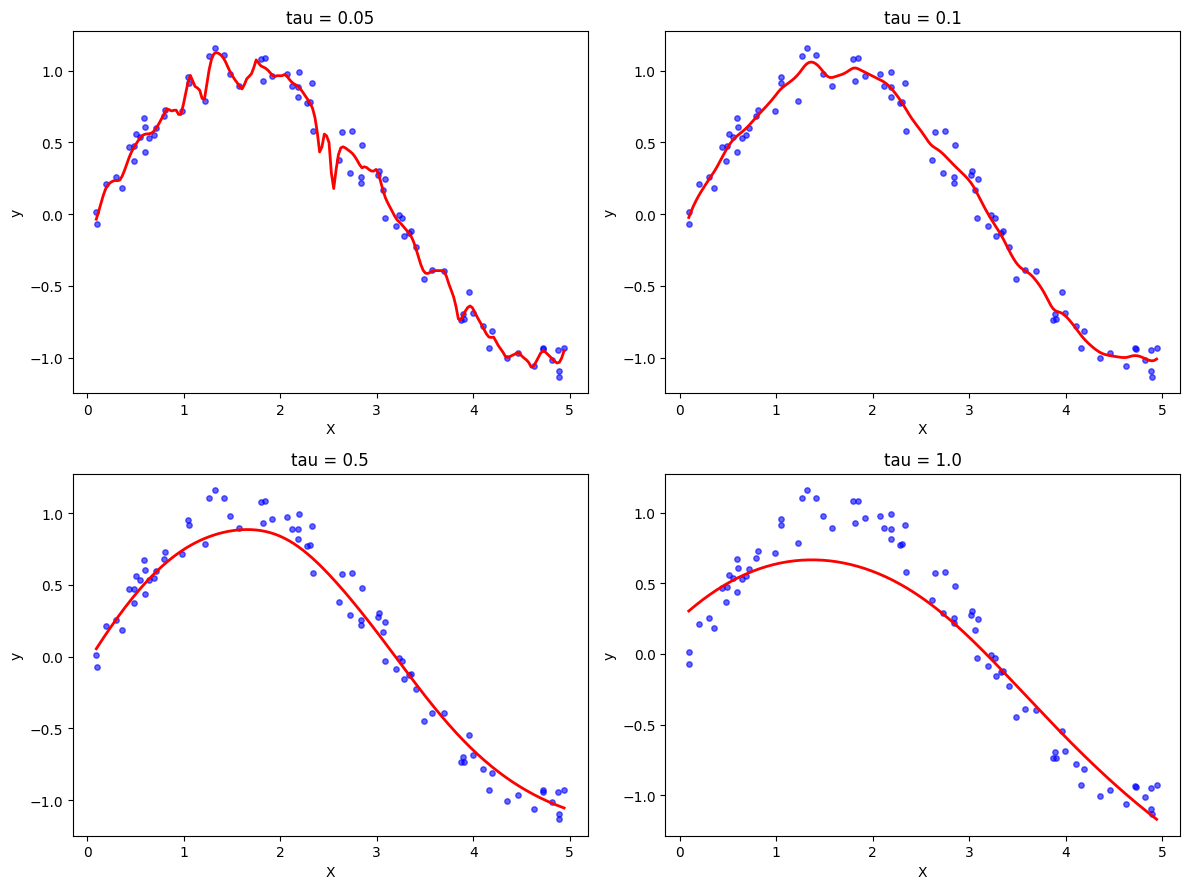

In [6]:
def fit_curve(X, y, tau, n_points=200):
    domain = np.linspace(X.min(), X.max(), n_points)
    preds = [local_regression(x0, X, y, tau) for x0 in domain]
    return domain, np.array(preds)

taus = [0.05, 0.1, 0.5, 1.0]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for tau, ax in zip(taus, axes.ravel()):
    domain, preds = fit_curve(X, y, tau)
    ax.scatter(X, y, color='blue', s=15, alpha=0.6)
    ax.plot(domain, preds, color='red', linewidth=2)
    ax.set_title(f'tau = {tau}')
    ax.set_xlabel('X')
    ax.set_ylabel('y')

plt.tight_layout()
plt.show()

## 6. All bandwidths on one plot

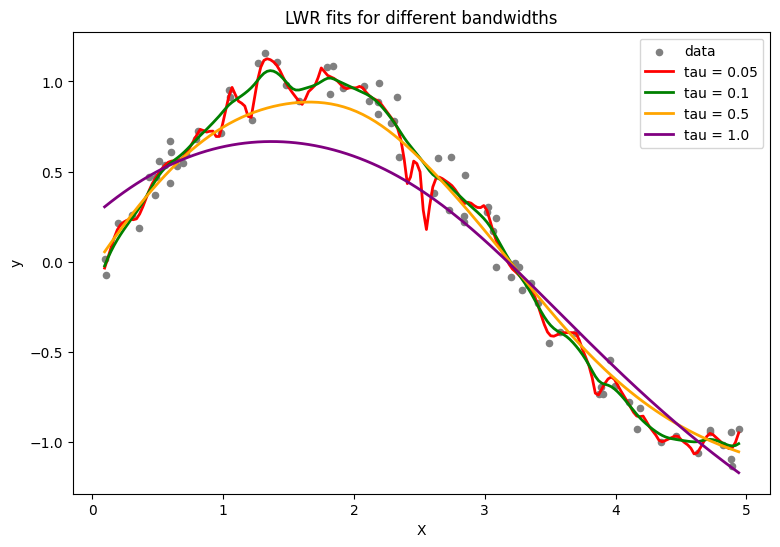

In [7]:
plt.figure(figsize=(9, 6))
plt.scatter(X, y, color='gray', s=20, label='data')

colors = ['red', 'green', 'orange', 'purple']
for tau, c in zip(taus, colors):
    domain, preds = fit_curve(X, y, tau)
    plt.plot(domain, preds, color=c, linewidth=2, label=f'tau = {tau}')

plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.title('LWR fits for different bandwidths')
plt.show()

## 7. Comparing the bandwidths

In [8]:
results = []
for tau in taus:
    _, preds = fit_curve(X, y, tau)
    results.append({'tau': tau, 'mean_prediction': preds.mean(), 'std_prediction': preds.std()})

pd.DataFrame(results)

,tau,mean_prediction,std_prediction
0,0.05,0.156936,0.713150
1,0.10,0.165735,0.716454
2,0.50,0.144195,0.652733
3,1.00,0.082544,0.587542


## Observations

tau = 0.05 hugs the noisy points and produces a jagged curve, basically overfitting to the noise. tau = 1.0 is too smooth and starts losing the shape of the sine wave. Somewhere around tau = 0.1 to 0.5 gives the best trade-off for this dataset, tracking the underlying sine curve without chasing every noisy point.